<a href="https://colab.research.google.com/github/4xuanzhou/GIS/blob/main/ps1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Community Health Assessment of New Jersey Communities Experiencing Compressor Station Construction or Expansion

The project aims to assess community health using data from CDC PLACES, with particular attention to health outcomes that may be relevant to environmental exposures associated with the proposed natural-gas Compressor Station 206 (CS206) in Somerset County and the expansion of Compressor Station 325 (CS325) in Sussex County. They are midstream infrastructure facilities designed to transport unconventional natural gas from the Marcellus Shale region in Pennsylvania to the consumer markets in the northeastern United States.

Previous studies conducted in the Marcellus Shale region have found associations between exposure to unconventional natural gas development and adverse health outcomes, including increased risk of asthma exacerbations (Rasmussen et al., 2016) and psychological symptoms such as depression and anxiety (Blinn et al., 2020). Therefore, the expansion of CS 325 in 2023 may be associated with changes in health outcomes in Sussex County and surrounding communities, while the construction of CS 206 in Somerset County, anticipated by the end of 2027, may present potential health challenges for Somerset and surrounding communities. Examining existing health outcomes in Sussex County and surrounding communities could provide a useful case example, while assessing current health outcomes in Somerset County and surrounding communities could establish a baseline for future monitoring.

Findings from this project will inform evidence-based recommendations for tracking community health and health disparities at the neighborhood level in Somerset County and surrounding communities as the CS 206 project progresses. Given the project background, Northern and Central New Jersey will be the primary area of interest.

#### Unit of Analysis

The unit of analysis for this project is the census tract. CDC PLACES provides health data at the census-tract level (Centers for Disease Control and Prevention, 2025). Median household income data from the source of ACS 5-year estimates (U.S. Census Bureau, 2024) is used to map the vulnerable populations. Natural gas compressor stations are marked on maps using data from 543rd Geospatial Planning Cell (2021).

Census tracts were selected because they allow for a more granular assessment of health disparities among neighborhoods surrounding the compressor stations. County-level data are not essential to this project because health outcomes potentially associated with compressor-station exposure may be diluted when aggregated across a large geographic area.

#### Research Questions

1. Is the 2023 expansion of Compressor Station 325 associated with changes in the prevalence of asthma and mental distress in Sussex County and surrounding communities?
2. Do communities located closer to Compressor Station 325 experience greater changes in the prevalence of asthma and mental distress following the expansion?
3. Based on evidence from the Station 325 case example, what recommendations can be made for establishing a baseline and monitoring community health and health disparities in Somerset County and surrounding communities as Compressor Station 206 progresses toward construction?

#### Hypotheses

1. The 2023 expansion of Compressor Station 325 is associated with an increase in the prevalence of asthma and mental distress in Sussex County and surrounding communities.
2. Communities located closer to Compressor Station 325 experience greater increases in the prevalence of asthma and mental distress following the 2023 expansion.


In [1]:
%%capture
#!pip install geopandas #==1.0.1
!pip install mapclassify #sometimes have to install library which you get from https://pypi.org/

In [2]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd #gis/maps: a sister of pandas; does the job;
#tho not as fancy-interactive as folium or leafmap https://geopandas.org/

import mapclassify #need for thematic map classification

import seaborn as sns

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

#from google.colab import data_table
#data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
from google.colab.data_table import DataTable
DataTable.max_columns = 250

In [3]:
#!python --version
gpd.__version__

'1.1.4'

In [4]:
import zipfile # Added: Import zipfile module

! wget -q -O nj0.zip https://github.com/4xuanzhou/GIS/raw/refs/heads/main/tl_2025_34_tract.zip
zip_ref = zipfile.ZipFile('nj0.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
!ls #see what we got

nj0=gpd.read_file('tl_2025_34_tract.shp') #load the shapefile with gpd as nj0

# nj0.dtypes
nj0.head()

nj0.zip		      tl_2025_34_tract.dbf  tl_2025_34_tract.shp.ea.iso.xml
sample_data	      tl_2025_34_tract.prj  tl_2025_34_tract.shp.iso.xml
tl_2025_34_tract.cpg  tl_2025_34_tract.shp  tl_2025_34_tract.shx


,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,34,021,002702,34021002702,1400000US34021002702,27.02,Census Tract 27.02,G5020,S,5399790,15413,+40.2169255,-074.7000479,"POLYGON ((-74.72001 40.22311, -74.71984 40.223..."
1,34,021,002800,34021002800,1400000US34021002800,28,Census Tract 28,G5020,S,2317338,1972,+40.2282073,-074.7235843,"POLYGON ((-74.73948 40.23151, -74.73939 40.231..."
2,34,021,002902,34021002902,1400000US34021002902,29.02,Census Tract 29.02,G5020,S,4990120,111611,+40.2363258,-074.7184493,"POLYGON ((-74.73856 40.23464, -74.73852 40.234..."
3,34,021,002904,34021002904,1400000US34021002904,29.04,Census Tract 29.04,G5020,S,7597739,49442,+40.2568316,-074.6776468,"POLYGON ((-74.69678 40.25125, -74.69669 40.251..."
4,34,033,020200,34033020200,1400000US34033020200,202,Census Tract 202,G5020,S,951186,0,+39.7320131,-075.4672011,"POLYGON ((-75.47565 39.7337, -75.47551 39.7337..."


In [5]:
# Make the map of NJ
# Not interested in South Jersey,
# so I will filter in the next steps and then plot Central and North Jersey
# nj0.plot()

A map of Northern and Central New Jersey is shown below.

<Axes: >

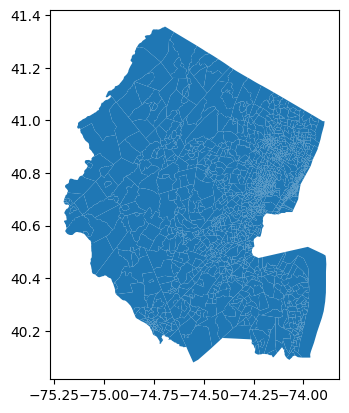

In [6]:


# Define the lists of counties for North and Central Jersey
north_counties = ['Bergen', 'Essex', 'Hudson', 'Morris', 'Passaic', 'Sussex', 'Warren']
central_counties = ['Hunterdon', 'Mercer', 'Middlesex', 'Monmouth', 'Somerset', 'Union']

# Combine them to get the full region
north_central_counties = north_counties + central_counties

# Manually created mapping of county names to FIPS codes for New Jersey
# These FIPS codes are standard 2-digit codes for NJ counties (as strings)
nj_county_fips_mapping = {
    'Atlantic': '001', 'Bergen': '003', 'Burlington': '005', 'Camden': '007',
    'Cape May': '009', 'Cumberland': '011', 'Essex': '013', 'Gloucester': '015',
    'Hudson': '017', 'Hunterdon': '019', 'Mercer': '021', 'Middlesex': '023',
    'Monmouth': '025', 'Morris': '027', 'Ocean': '029', 'Passaic': '031',
    'Salem': '033', 'Somerset': '035', 'Sussex': '037', 'Union': '039',
    'Warren': '041'
}

# Get the FIPS codes for the North and Central counties
north_central_counties_fips = [
    nj_county_fips_mapping[county_name]
    for county_name in north_central_counties
    if county_name in nj_county_fips_mapping
]
#north_central_counties_fips

# Filter the GeoDataFrame using COUNTYFP column and FIPS codes
filtered_map = nj0[nj0['COUNTYFP'].isin(north_central_counties_fips)]
filtered_map.plot()

In [7]:
filtered_map.head()
filtered_map.dtypes
filtered_map.columns
filtered_map.shape[0]

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,34,021,002702,34021002702,1400000US34021002702,27.02,Census Tract 27.02,G5020,S,5399790,15413,+40.2169255,-074.7000479,"POLYGON ((-74.72001 40.22311, -74.71984 40.223..."
1,34,021,002800,34021002800,1400000US34021002800,28,Census Tract 28,G5020,S,2317338,1972,+40.2282073,-074.7235843,"POLYGON ((-74.73948 40.23151, -74.73939 40.231..."
2,34,021,002902,34021002902,1400000US34021002902,29.02,Census Tract 29.02,G5020,S,4990120,111611,+40.2363258,-074.7184493,"POLYGON ((-74.73856 40.23464, -74.73852 40.234..."
3,34,021,002904,34021002904,1400000US34021002904,29.04,Census Tract 29.04,G5020,S,7597739,49442,+40.2568316,-074.6776468,"POLYGON ((-74.69678 40.25125, -74.69669 40.251..."
8,34,003,036200,34003036200,1400000US34003036200,362,Census Tract 362,G5020,S,4775003,108396,+40.8413344,-074.0576708,"POLYGON ((-74.07879 40.84239, -74.07751 40.843..."


,0
STATEFP,object
COUNTYFP,object
TRACTCE,object
GEOID,object
GEOIDFQ,object
NAME,object
NAMELSAD,object
MTFCC,object
FUNCSTAT,object
ALAND,int64


Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'geometry'],
      dtype='object')

1547

In [8]:
'''
# I need to see the county names and boundaries (CLAUD helped write the code below)
# Dissolve tracts up to county level (one polygon per county)
county_map = filtered_map.dissolve(by='COUNTYFP')

# Make a 10×10 inch square figure
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the tract-level polygons (thin, light lines)
filtered_map.plot(ax=ax, color='whitesmoke', edgecolor='lightgray', linewidth=0.4)

# Overlay county boundaries (thicker, darker lines) so they stand out
county_map.boundary.plot(ax=ax, color='black', linewidth=1.2)

# Add county name labels at each county's centroid
# Use the global nj_county_fips_mapping for consistency and reverse it to get fips_to_name
fips_to_name = {fips: name for name, fips in nj_county_fips_mapping.items() if fips in north_central_counties_fips}

for fips, row in county_map.iterrows():
    centroid = row.geometry.centroid
    name = fips_to_name.get(fips, fips) # Use .get() with default for safety
    ax.annotate(
        name,
        xy=(centroid.x, centroid.y),
        ha='center', va='center',
        fontsize=8, fontweight='bold', color='darkred'
    )
# Add title
ax.set_title("Northern and Central New Jersey", fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.show()
'''

'\n# I need to see the county names and boundaries (CLAUD helped write the code below)\n# Dissolve tracts up to county level (one polygon per county)\ncounty_map = filtered_map.dissolve(by=\'COUNTYFP\')\n\n# Make a 10×10 inch square figure\nfig, ax = plt.subplots(figsize=(10, 10))\n\n# Plot the tract-level polygons (thin, light lines)\nfiltered_map.plot(ax=ax, color=\'whitesmoke\', edgecolor=\'lightgray\', linewidth=0.4)\n\n# Overlay county boundaries (thicker, darker lines) so they stand out\ncounty_map.boundary.plot(ax=ax, color=\'black\', linewidth=1.2)\n\n# Add county name labels at each county\'s centroid\n# Use the global nj_county_fips_mapping for consistency and reverse it to get fips_to_name\nfips_to_name = {fips: name for name, fips in nj_county_fips_mapping.items() if fips in north_central_counties_fips}\n\nfor fips, row in county_map.iterrows():\n    centroid = row.geometry.centroid\n    name = fips_to_name.get(fips, fips) # Use .get() with default for safety\n    ax.annota

In [9]:
# Load the csv of CDC PLACES
!wget -O cdc_places_tract_data.csv "https://github.com/4xuanzhou/GIS/releases/download/v1.0/PLACES__Census_Tract_Data_.GIS_Friendly_Format._2025_release_20260917.csv"

cdc0 = pd.read_csv("cdc_places_tract_data.csv")
#cdc0.columns
#cdc0.head()


--2026-09-24 16:10:18--  https://github.com/4xuanzhou/GIS/releases/download/v1.0/PLACES__Census_Tract_Data_.GIS_Friendly_Format._2025_release_20260917.csv
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1356505801/93a63ac5-01d2-4ed4-a433-6f9f0ca897ae?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-24T17%3A06%3A12Z&rscd=attachment%3B+filename%3DPLACES__Census_Tract_Data_.GIS_Friendly_Format._2025_release_20260917.csv&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-09-24T16%3A05%3A34Z&ske=2026-09-24T17%3A06%3A12Z&sks=b&skv=2018-11-09&sig=LqkmvQg6IEghFwK8m794EaCXhf7wGDXcjcwSYH7nk2M%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY

In [10]:
# Select the New Jersey observations from CDC Places large dataset
cdc_nj = cdc0[cdc0['StateAbbr']=='NJ']
#cdc_nj.head()

# Select north and central NJ counties
# since these are places of interest in this study
cdc_northern_central_nj = cdc_nj[cdc_nj['CountyName'].isin(north_central_counties)]
#cdc_northern_central_nj.head()
#cdc_northern_central_nj.columns
mh_asthma = cdc_northern_central_nj[['StateAbbr', 'StateDesc', 'CountyName', 'CountyFIPS', 'TractFIPS', 'TotalPopulation', 'TotalPop18plus', 'CASTHMA_CrudePrev', 'CASTHMA_Crude95CI', 'MHLTH_CrudePrev', 'MHLTH_Crude95CI']]
#mh_asthma.head()
# check unique "CountyName" in cdc_northern_central_nj
# cdc_northern_central_nj['CountyName'].unique()

In [11]:
# Convert TractFIPS to string; make GEOID have 11 digits
mh_asthma['TractFIPS'] = mh_asthma['TractFIPS'].astype(str).str.zfill(11)

# Make sure filtered_map's GEOID is also a string for a clean match
filtered_map['GEOID'] = filtered_map['GEOID'].astype(str)

# Merge
a1 = pd.merge(filtered_map, mh_asthma, left_on='GEOID', right_on='TractFIPS', how='outer', indicator=True)

/tmp/ipykernel_1057/3322450607.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mh_asthma['TractFIPS'] = mh_asthma['TractFIPS'].astype(str).str.zfill(11)
/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [12]:
# check missing data
a1['_merge'].value_counts()
#a1.head()

print(a1['CASTHMA_CrudePrev'].isna().sum())          # count of missing/NaN ASTHMA
print((a1['CASTHMA_CrudePrev'] < 0).sum())           # count of suppressed placeholder codes

print(a1['MHLTH_CrudePrev'].isna().sum())          # count of missing/NaN ASTHMA
print((a1['MHLTH_CrudePrev'] < 0).sum())           # count of suppressed placeholder codes

,count
_merge,
both,1542
left_only,5
right_only,0


5
0
5
0


In [13]:
#a1.dtypes


#### Prevalence of current asthma among adults

The data source of prevalence of current asthma among adults is CDC PLACES (Centers for Disease Control and Prevention, 2025). 5 of the 1547 census tracts had missing asthma prevalence estimates, due to unreliable small-area modeling estimates for those tracts. These tracts appear blank in the plot titled "Model-based estimate for crude prevalence of current asthma among adults, 2023." Red tracts have higher prevalence of current asthma among adults, and green tracts have lower prevalence of current asthma among adults.

The plot indicates that Essex county area has highest prevalence of current asthma. The Sussex county area has relatively high prevalence of current asthma, and the central and northeast New Jersey has lower prevalence of current asthma.

<Axes: >

[]

[]

Text(0.5, 80.7222222222222, 'source/definition: https://data.cdc.gov/500-Cities-Places/PLACES-Census-Tract-Data-GIS-Friendly-Format-2025-/yjkw-uj5s/about_data')

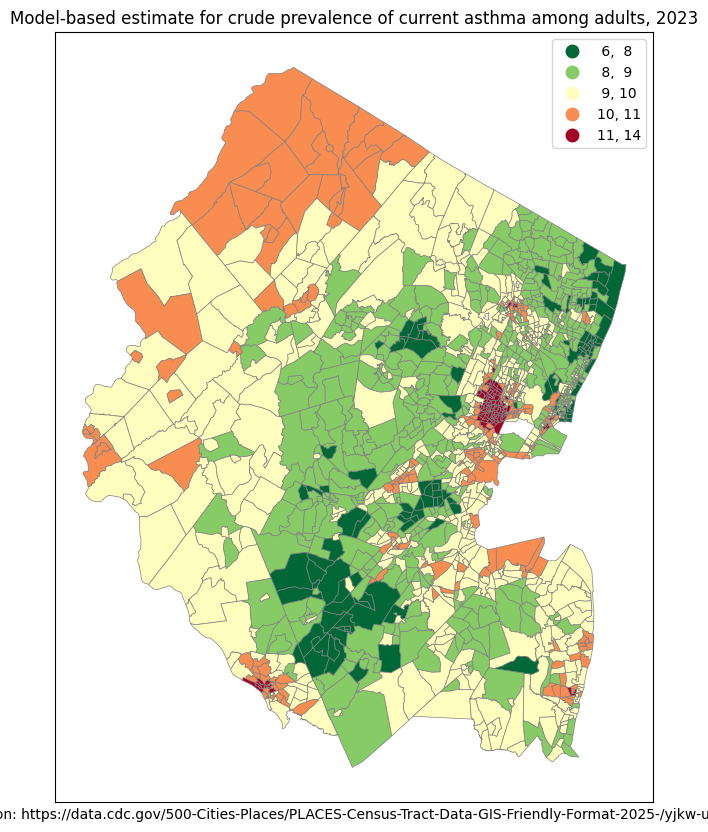

In [14]:
fig, ax = plt.subplots(figsize=(10,10))
a1.plot(ax=ax,column='CASTHMA_CrudePrev',legend=True,cmap='RdYlGn_r',
          scheme='natural_breaks',k=5, edgecolor='grey',linewidth=.5,legend_kwds= {"fmt": "{:,.0f}"})
ax.title.set_text("Model-based estimate for crude prevalence of current asthma among adults, 2023")
ax.set_xticks([]) #kills xticks
ax.set_yticks([]) #kills xticks
ax.set_xlabel('''source/definition: https://data.cdc.gov/500-Cities-Places/PLACES-Census-Tract-Data-GIS-Friendly-Format-2025-/yjkw-uj5s/about_data''')



#### Prevalence of frequent mental distress among adults

The data source of prevalence of frequent mental distress among adults is CDC PLACES (Centers for Disease Control and Prevention, 2025). 5 of the 1547 census tracts had missing estimates of frequent mental distress, due to unreliable small-area modeling estimates for those tracts. These tracts appear blank in the plot titled "Model-based estimate for crude prevalence of frequent mental distress among adults, 2023." Darker red tracts have higher prevalence of frequent mental distress among adults, and lighter red tracts have lower prevalence of frequent mental distress among adults.

The plot indicates that Essex county area and part of Bergen County has highest prevalence of frequent mental distress. The Sussex county area has relatively high prevalence of frequent mental distress, and most of the central New Jersey has lower prevalence of frequent mental distress.

<Axes: >

[]

[]

Text(0.5, 80.7222222222222, 'source/definition: https://data.cdc.gov/500-Cities-Places/PLACES-Census-Tract-Data-GIS-Friendly-Format-2025-/yjkw-uj5s/about_data')

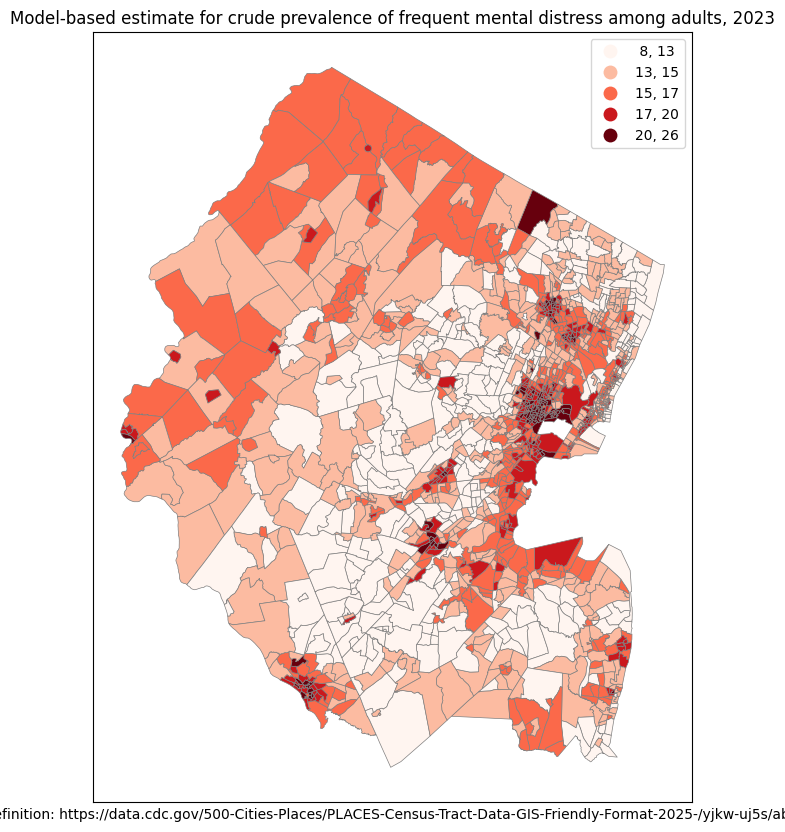

In [15]:
fig, ax = plt.subplots(figsize=(10,10))
a1.plot(ax=ax,column='MHLTH_CrudePrev',legend=True,cmap='Reds',
          scheme='natural_breaks',k=5, edgecolor='grey',linewidth=.5,legend_kwds= {"fmt": "{:,.0f}"})
ax.title.set_text("Model-based estimate for crude prevalence of frequent mental distress among adults, 2023")
ax.set_xticks([]) #kills xticks
ax.set_yticks([]) #kills yticks
ax.set_xlabel('''source/definition: https://data.cdc.gov/500-Cities-Places/PLACES-Census-Tract-Data-GIS-Friendly-Format-2025-/yjkw-uj5s/about_data''')

In [16]:
# Load the csv of ACS NJ median household income in the past 12 months
!wget -O ACSDT5Y2024.B19013-Data.csv "https://github.com/4xuanzhou/GIS/raw/refs/heads/main/ACSDT5Y2024.B19013-Data.csv"

mhi = pd.read_csv("ACSDT5Y2024.B19013-Data.csv")
#mhi.dtypes
#mhi.head()

# Remove the explanatory row (the one under the header row)
mhi = mhi.drop(index=0).reset_index(drop=True)

# Convert 'B19013_001E' to numeric, coercing errors to NaN
mhi['B19013_001E'] = pd.to_numeric(mhi['B19013_001E'], errors='coerce')

# Extract the standard tract GEOID from the long GEO_ID string
# e.g., '1400000US34001000100' -> '34001000100'
mhi['GEOID'] = mhi['GEO_ID'].str.split('US').str[1]

# Make sure it's a clean string
mhi['GEOID'] = mhi['GEOID'].astype(str)
mhi.head()

--2026-09-24 16:10:31--  https://github.com/4xuanzhou/GIS/raw/refs/heads/main/ACSDT5Y2024.B19013-Data.csv
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/4xuanzhou/GIS/refs/heads/main/ACSDT5Y2024.B19013-Data.csv [following]
--2026-09-24 16:10:32--  https://raw.githubusercontent.com/4xuanzhou/GIS/refs/heads/main/ACSDT5Y2024.B19013-Data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 194127 (190K) [text/plain]
Saving to: ‘ACSDT5Y2024.B19013-Data.csv’

ACSDT5Y2024.B19013- 100%[===================>] 189.58K  --.-KB/s    in 0.005s  

2026-09-24 16:10:32 (38.4 MB/s) - ‘ACSDT5Y2024.B19013-Data.

,GEO_ID,NAME,B19013_001E,B19013_001M,Unnamed: 4,GEOID
0,1400000US34001000100,Census Tract 1; Atlantic County; New Jersey,56222.0,13213,NaN,34001000100
1,1400000US34001000200,Census Tract 2; Atlantic County; New Jersey,42346.0,28560,NaN,34001000200
2,1400000US34001000300,Census Tract 3; Atlantic County; New Jersey,52763.0,18124,NaN,34001000300
3,1400000US34001000400,Census Tract 4; Atlantic County; New Jersey,50104.0,13921,NaN,34001000400
4,1400000US34001000500,Census Tract 5; Atlantic County; New Jersey,53378.0,14617,NaN,34001000500


In [17]:
# merge filtered_map and mhi
a2 = pd.merge(filtered_map, mhi, left_on='GEOID', right_on='GEOID',how='inner',indicator=True)

# Explicitly convert 'B19013_001E' to numeric after merge
a2['B19013_001E'] = pd.to_numeric(a2['B19013_001E'], errors='coerce')

# check missing data
print(a2['B19013_001E'].isna().sum())          # count of missing/NaN income values
print((a2['B19013_001E'] < 0).sum())           # count of suppressed placeholder codes

#a2.dtypes
#a2.head(3)
a2['_merge'].value_counts()

56
0


,count
_merge,
both,1547
left_only,0
right_only,0


#### Median Household income

Median household income data is from the source of ACS 5-year estimates (U.S. Census Bureau, 2024). 56 of the 1,547 census tracts had unavailable median household income data in the ACS 5-year estimates, due to small population samples in those tracts. These tracts appear blank in the plot titled "Median Household Income in the Past 12 Months (in 2024 Inflation-Adjusted Dollars)." Tracts in darker blue have higher median household income. Tracts in ligher blue have lower median household income.

The neighborhoods in central and northeast of New Jersey tend to have higher median household income, while the northwest of New Jersey tend to have lower median household income.

<Axes: >

[]

[]

Text(0.5, 80.7222222222222, 'source/definition: https://data.census.gov/table?q=B19013&g=040XX00US34$1400000')

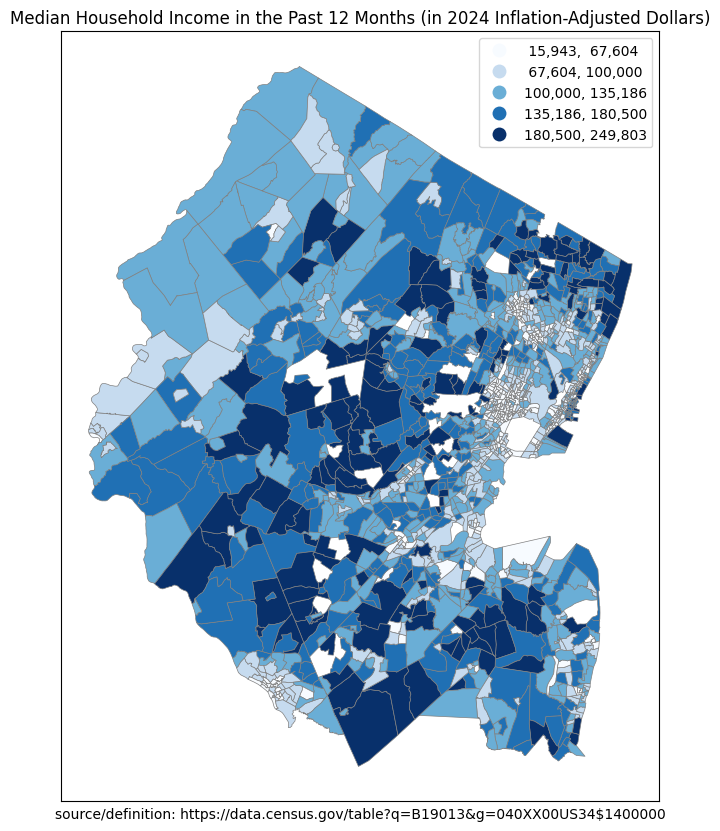

In [18]:
fig, ax = plt.subplots(figsize=(10,10))
a2_plot_data = a2.dropna(subset=['B19013_001E'])
a2_plot_data.plot(ax=ax,column='B19013_001E',legend=True,cmap='Blues',
          scheme='natural_breaks',k=5, edgecolor='grey',linewidth=.5,legend_kwds= {"fmt": "{:,.0f}"})
ax.title.set_text("Median Household Income in the Past 12 Months (in 2024 Inflation-Adjusted Dollars)")
ax.set_xticks([]) #kills xticks
ax.set_yticks([]) #kills xticks
ax.set_xlabel('''source/definition: https://data.census.gov/table?q=B19013&g=040XX00US34$1400000''')

In [23]:
# get shapefile of natural gas compressor stations
!wget -q -O cs.zip  https://github.com/4xuanzhou/GIS/raw/refs/heads/main/Natural_Gas_Compressor_Stations.zip
zip_ref = zipfile.ZipFile('cs.zip', 'r');zip_ref.extractall(); zip_ref.close()
# cs0 is national
cs0 = gpd.read_file('Natural_Gas_Compressor_Stations.shp')
#cs0.dtypes
#cs0.head(3)

In [27]:
# Limit to STATE "NJ"
cs = cs0[cs0['STATE'] == 'NJ']
# cs only has NJ compressor stations

# Check duplicates in cs0,
dupes = cs[cs.duplicated(subset='NAME', keep=False)]
print(dupes[['NAME', 'LATITUDE', 'LONGITUDE', 'OPERATOR', 'GCOMPID', 'OBJECTID', 'STATE', 'CITY', 'ADDRESS']])
# Checked other info to confirm these were true duplicates, not distinct stations
# I decided to keep them, because their operators are different, so maybe they are different facilities

        NAME   LATITUDE  LONGITUDE                         OPERATOR  \
240  HANOVER  40.791597 -74.429208   TEXAS EASTERN TRANSMISSION, LP   
952  HANOVER  40.799881 -74.427718  ALGONQUIN GAS TRANSMISSION, LLC   

       GCOMPID  OBJECTID STATE        CITY               ADDRESS  
240  GCOMP1214       241    NJ  MORRISTOWN  OFF OF COLUMBIA TPKE  
952   GCOMP625       953    NJ  MORRISTOWN         45 AIRPORT RD  


#### Natrual gas compressor stations

The data source of natural gas compressor station is from 543rd Geospatial Planning Cell (2021). The compressor stations that have been built by 2021 are reflected in the plot titled "Natural Gas Compressor Stations in Northern and Central New Jersey." CS 325 in Sussex County that we are interested in is included. It's notable that 'Franklin (Freehold)' on the plot refers to Freehold Compressor Station, different from the newly proposed Compressor Station 206 (CS 206). CS 206 hasn't been constructed and is not reflected on the plot.

<Axes: >

<Axes: >

Text(3, 3, 'LINDEN')

Text(3, 3, 'HANOVER')

Text(3, 3, 'LAMBERTVILLE')

...

Text(3, 3, 'OTHER: NO. 240 HACKENSACK MEADOWS')

Text(0.5, 1.0, 'Natural Gas Compressor Stations in Northern and Central New Jersey')

[]

[]

Text(0.5, 80.7222222222222, 'source/definition: https://543rd-gpc-hub-543rd.hub.arcgis.com/datasets/543rd::natural-gas-compressor-stations/explore')

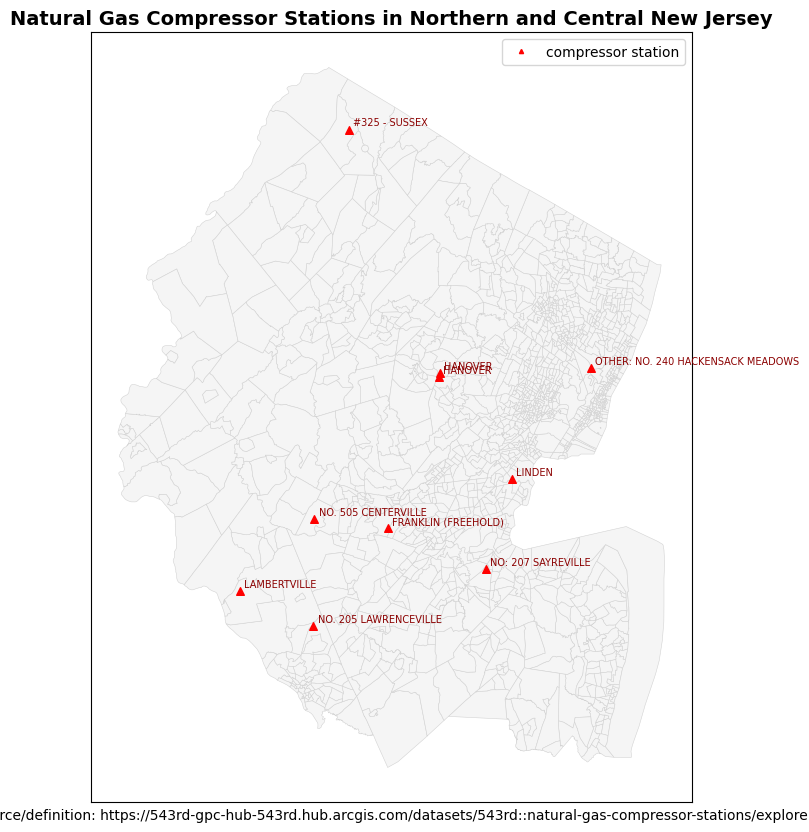

In [28]:
# The CRS-checking (.crs) and spatial join (sjoin) steps below were done with help from Claude

# Check/match CRS first
if cs.crs != filtered_map.crs:
    cs = cs.to_crs(filtered_map.crs)

# Spatial join: filters the compressor stations to keep only the ones whose location falls within the tract polygons for our region,
# since there's no shared ID column to .merge() on — only coordinates.
compressors_in_region = gpd.sjoin(cs, filtered_map, predicate='within', how='inner')

# Now plot the filtered stations
fig, ax = plt.subplots(1, figsize=(10,10))
filtered_map.plot(ax=ax, color='whitesmoke', edgecolor='lightgray', linewidth=0.4)
compressors_in_region.plot(ax=ax, color='red', markersize=30, marker='^', label='Compressor Stations')
# Add station names
for idx, row in compressors_in_region.iterrows():
    ax.annotate(
        row['NAME_left'], # Changed 'NAME' to 'NAME_left'
        xy=(row.geometry.x, row.geometry.y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=7, color='darkred'
    )
ax.set_title("Natural Gas Compressor Stations in Northern and Central New Jersey", fontsize=14, fontweight='bold')
ax.set_xticks([])
ax.set_yticks([])
#plt.show()
ax.set_xlabel('''source/definition: https://543rd-gpc-hub-543rd.hub.arcgis.com/datasets/543rd::natural-gas-compressor-stations/explore''')

from matplotlib.lines import Line2D
point = Line2D([0], [0], label='compressor station', marker='^', markersize=3,
         markeredgecolor='r', markerfacecolor='r', linestyle='')
plt.legend(handles=[point])
plt.show()

#### Combined map of compressor stations and prevalence of asthma (not for causal inference purposes)

The combined map of compressor stations and prevalence of current asthma among adults shows that the neighborhoods around CS 325 in Sussex County have relatively high prevalence of current asthma among adults. The asthma prevalence data is collected by Behavioral Risk Factor Surveillance System (BRFSS) in 2023, and CS 325 was expanded from 2022 to 2023. Estimates of emission increases from new construction or other expansions at this site is large (Environmental Integrity Project, 2024). The surrounding communities have some exposure from the expansion of CS 325 when they reported their asthma conditions.

However, the map doesn't indicate any causal relationships. In addition to that, the other natural gas compressor staions on this map doesn't necessarily have significant emissions during their construction, expansion, or operation. Therefore, the causal link between any of these compressor stations and their surrounding communities should not be inferred from this map. More pollution data may be evaluated to understand the complex relationships.

<Axes: >

<Axes: >

Text(3, 3, 'LINDEN')

Text(3, 3, 'HANOVER')

Text(3, 3, 'LAMBERTVILLE')

...

Text(3, 3, 'NO. 505 CENTERVILLE')

Text(3, 3, 'OTHER: NO. 240 HACKENSACK MEADOWS')

[]

[]

Text(0.5, 80.7222222222222, 'Asthma data source: https://data.cdc.gov/500-Cities-Places/PLACES-Census-Tract-Data-GIS-Friendly-Format-2025-/yjkw-uj5s/about_data\nCompressor station source: https://543rd-gpc-hub-543rd.hub.arcgis.com/datasets/543rd::natural-gas-compressor-stations/explore')

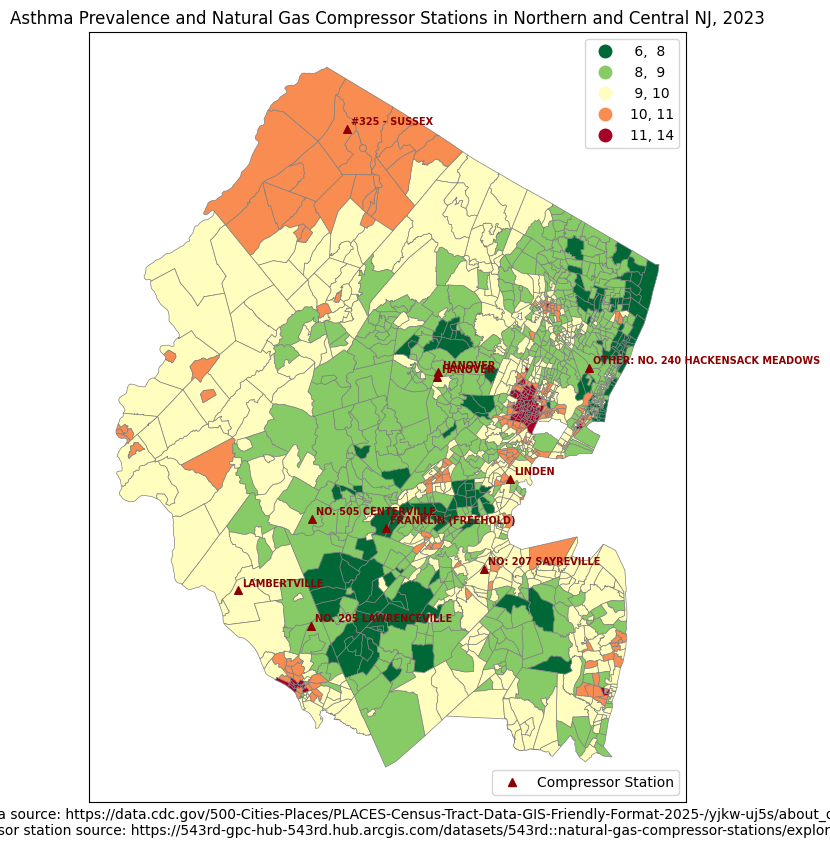

In [22]:
fig, ax = plt.subplots(figsize=(10,10))

# Asthma prevalence choropleth as the base layer
a1.plot(ax=ax, column='CASTHMA_CrudePrev', legend=True, cmap='RdYlGn_r',
        scheme='natural_breaks', k=5, edgecolor='grey', linewidth=.5,
        legend_kwds={"fmt": "{:,.0f}"})

# Grab a reference to the asthma legend BEFORE it gets overwritten
asthma_legend = ax.get_legend()

# Overlay compressor stations
compressors_in_region.plot(ax=ax, color='darkred', markersize=30, marker='^')

for idx, row in compressors_in_region.iterrows():
    ax.annotate(
        row['NAME_left'],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=7, color='darkred', fontweight='bold'
    )

ax.title.set_text("Asthma Prevalence and Natural Gas Compressor Stations in Northern and Central NJ, 2023")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('''Asthma data source: https://data.cdc.gov/500-Cities-Places/PLACES-Census-Tract-Data-GIS-Friendly-Format-2025-/yjkw-uj5s/about_data
Compressor station source: https://543rd-gpc-hub-543rd.hub.arcgis.com/datasets/543rd::natural-gas-compressor-stations/explore''')

# Re-add the asthma legend
ax.add_artist(asthma_legend)

# Add the compressor station legend without wiping out the asthma one
from matplotlib.lines import Line2D
point = Line2D([0], [0], label='Compressor Station', marker='^', markersize=6,
               markeredgecolor='darkred', markerfacecolor='darkred', linestyle='')
ax.legend(handles=[point], loc='lower right')

plt.show()

#### References

543rd Geospatial Planning Cell. (2021). *Natural gas compressor stations* [Data set]. ArcGIS. https://543rd-gpc-hub-543rd.hub.arcgis.com/datasets/543rd::natural-gas-compressor-stations/explore

Anthropic. (2026). *Claude (Sonnet 5)* [Large language model]. https://claude.ai

Blinn, H. N., Utz, R. M., Greiner, L. H., & Brown, D. R. (2020). Exposure assessment of adults living near unconventional oil and natural gas development and reported health symptoms in southwest Pennsylvania, USA. *PLOS ONE, 15*(8), e0237325. https://doi.org/10.1371/journal.pone.0237325

Centers for Disease Control and Prevention. (2025). *PLACES: Census tract data (GIS friendly format), 2025 release* [Data set]. https://data.cdc.gov/500-Cities-Places/PLACES-Census-Tract-Data-GIS-Friendly-Format-2025-/yjkw-uj5s/about_data

Environmental Integrity Project. (2024). *Compressor Station 325*. Oil & Gas Watch. https://oilandgaswatch.org/facility/3799

U.S. Census Bureau. (2024). *Median household income in the past 12 months (in 2024 inflation-adjusted dollars): 2024 ACS 5-year estimates, Table B19013* [Data set]. https://data.census.gov/table/ACSDT5Y2024.B19013

Rasmussen, S. G., Ogburn, E. L., McCormack, M., Casey, J. A., Bandeen-Roche, K., Mercer, D. G., & Schwartz, B. S. (2016). Association between unconventional natural gas development in the Marcellus Shale and asthma exacerbations. *JAMA Internal Medicine, 176*(9), 1334–1343. https://doi.org/10.1001/jamainternmed.2016.2436